In [1]:
import geopandas as gpd
import pandas as pd

basline_blocks = gpd.read_file('./data/gatchina/blocks_agg_with_indicators.geojson')
basline_blocks.head()

,residential,business,recreation,industrial,transport,special,agriculture,land_use,share,footprint_area,...,non_living_area,population,site_area,fsi,gsi,mxi,l,morphotype,area_accessibility,geometry
0,0.690207,0.211718,0.055976,0.0,0.042093,0.0,0.0,LandUse.RESIDENTIAL,0.690207,7383.849525,...,9195.928868,30.0,836277.821580,0.012109,0.008829,0.091908,1.371459,individual residential,10.063987,"POLYGON ((30.09367 59.55207, 30.09375 59.55215..."
1,0.970519,0.029484,0.000000,0.0,0.000000,0.0,0.0,LandUse.RESIDENTIAL,0.970519,15304.958732,...,25627.346987,2000.0,420144.041613,0.212156,0.036428,0.712492,5.824002,mid-rise,10.210398,"POLYGON ((30.09448 59.56164, 30.09448 59.56164..."
2,0.936589,0.010562,0.052849,0.0,0.000000,0.0,0.0,LandUse.RESIDENTIAL,0.936589,17141.628200,...,19679.266138,2275.0,302985.560227,0.303551,0.056576,0.786029,5.365401,mid-rise,8.669212,"POLYGON ((30.12546 59.58002, 30.12541 59.57998..."
3,0.121353,0.819171,0.059489,0.0,0.000000,0.0,0.0,LandUse.BUSINESS,0.819171,9453.530183,...,17349.402634,134.0,124546.982903,0.173716,0.075903,0.198114,2.288643,low-rise model,7.467434,"POLYGON ((30.12501 59.56588, 30.12497 59.56582..."
4,0.068737,0.931312,0.000000,0.0,0.000000,0.0,0.0,LandUse.BUSINESS,0.931312,8567.309559,...,16945.739375,56.0,119574.990985,0.156696,0.071648,0.095598,2.187029,low-rise model,8.285434,"POLYGON ((30.1249 59.56574, 30.12497 59.56582,..."


In [2]:
cols = [
    'residential','business','recreation','industrial','transport','special',
    'agriculture','land_use','share','footprint_area','build_floor_area',
    'living_area','non_living_area','population','site_area','fsi','gsi',
    'mxi','l','morphotype','area_accessibility', 'geometry'
]
basline_blocks = basline_blocks[cols]


In [3]:
from catboost import CatBoostRegressor
model = CatBoostRegressor()
model.load_model('./data/catboost_model.cbm')  # модель на лог-цене
print(len(model.feature_names_))

121


In [4]:
feature_cols = [
'residential','business','recreation','industrial','transport','special',
'agriculture','land_use','share','footprint_area','build_floor_area',
'living_area','non_living_area','population','site_area','fsi','gsi',
'mxi','l','morphotype','area_accessibility'
]
cat_features = ['land_use', 'morphotype']
numeric_feats = [c for c in feature_cols if c not in cat_features]

In [5]:
basline_blocks['residential'] = basline_blocks['residential'].astype('float64')

In [6]:
from catboost import CatBoostRegressor

from urbanomy.methods.land_value_modeling import LandPriceEstimator

estimator = LandPriceEstimator(
    model=model,
    orig_features=numeric_feats+cat_features,
    categorical_features=cat_features,
    blocks=basline_blocks, #or blocks_198
)
blocks_pred = estimator.predict()

blocks_pred.head()

,residential,business,recreation,industrial,transport,special,agriculture,land_use,share,footprint_area,...,population,site_area,fsi,gsi,mxi,l,morphotype,area_accessibility,geometry,land_value
0,0.690207,0.211718,0.055976,0.0,0.042093,0.0,0.0,LandUse.RESIDENTIAL,0.690207,7383.849525,...,30.0,836277.821580,0.012109,0.008829,0.091908,1.371459,individual residential,10.063987,"POLYGON ((30.09367 59.55207, 30.09375 59.55215...",6.833466e+08
1,0.970519,0.029484,0.000000,0.0,0.000000,0.0,0.0,LandUse.RESIDENTIAL,0.970519,15304.958732,...,2000.0,420144.041613,0.212156,0.036428,0.712492,5.824002,mid-rise,10.210398,"POLYGON ((30.09448 59.56164, 30.09448 59.56164...",8.727378e+08
2,0.936589,0.010562,0.052849,0.0,0.000000,0.0,0.0,LandUse.RESIDENTIAL,0.936589,17141.628200,...,2275.0,302985.560227,0.303551,0.056576,0.786029,5.365401,mid-rise,8.669212,"POLYGON ((30.12546 59.58002, 30.12541 59.57998...",6.121753e+08
3,0.121353,0.819171,0.059489,0.0,0.000000,0.0,0.0,LandUse.BUSINESS,0.819171,9453.530183,...,134.0,124546.982903,0.173716,0.075903,0.198114,2.288643,low-rise model,7.467434,"POLYGON ((30.12501 59.56588, 30.12497 59.56582...",1.809802e+08
4,0.068737,0.931312,0.000000,0.0,0.000000,0.0,0.0,LandUse.BUSINESS,0.931312,8567.309559,...,56.0,119574.990985,0.156696,0.071648,0.095598,2.187029,low-rise model,8.285434,"POLYGON ((30.1249 59.56574, 30.12497 59.56582,...",1.709968e+08


count       345.000000
mean     135312.357566
std       73381.090181
min        1956.969214
25%       65113.869242
50%      151276.294259
75%      201065.711103
max      259942.812034
Name: price_per_sotka, dtype: float64


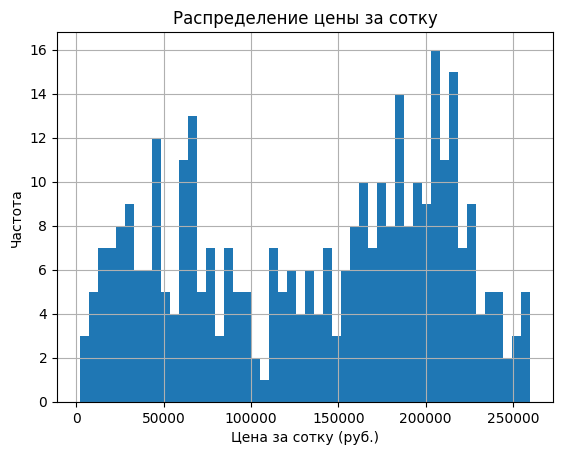

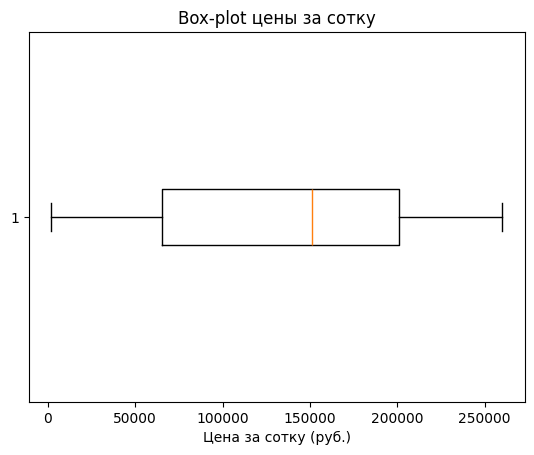

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# 1) Цена за сотку (100 м²)
blocks_pred["price_per_sotka"] = blocks_pred["land_value"] / blocks_pred["site_area"] * 100

# 2) Заменяем inf на NaN
blocks_pred["price_per_sotka"] = blocks_pred["price_per_sotka"].replace([np.inf, -np.inf], np.nan)

# 3) Удаляем выбросы: оставляем данные до 99-го перцентиля
p99 = blocks_pred["price_per_sotka"].quantile(0.99)
blocks_clean = blocks_pred[blocks_pred["price_per_sotka"] <= p99].copy()

print(blocks_clean["price_per_sotka"].describe())

# 4) Гистограмма после очистки
plt.figure()
blocks_clean["price_per_sotka"].dropna().hist(bins=50)
plt.xlabel("Цена за сотку (руб.)")
plt.ylabel("Частота")
plt.title("Распределение цены за сотку")
plt.show()

# 5) Box-plot после очистки
plt.figure()
plt.boxplot(blocks_clean["price_per_sotka"].dropna(), vert=False)
plt.xlabel("Цена за сотку (руб.)")
plt.title("Box-plot цены за сотку")
plt.show()


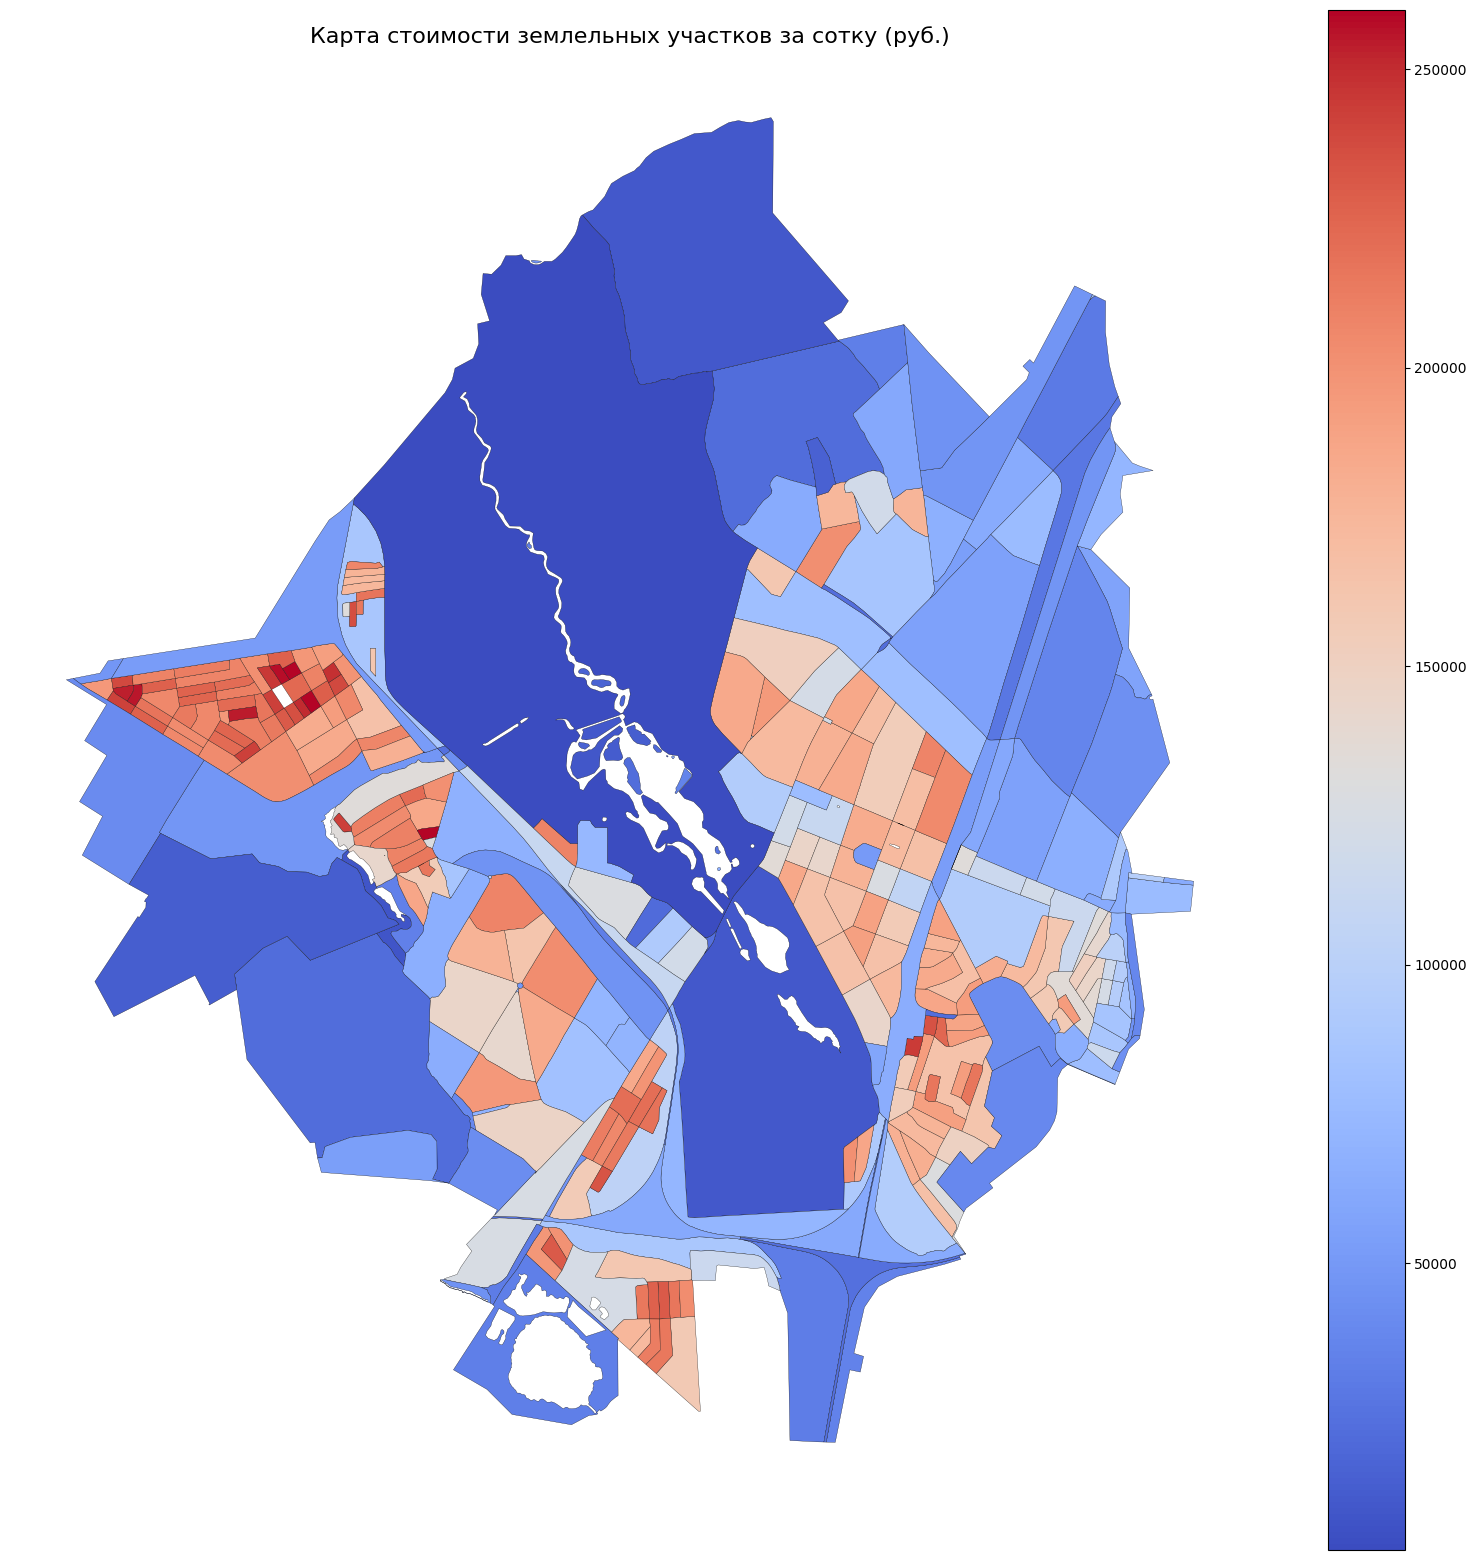

In [8]:
import matplotlib.pyplot as plt

blocks_clean.plot(
    column='price_per_sotka',
    legend=True,
    figsize=(20,20),
    cmap='coolwarm',
    edgecolor='black',   # <-- цвет границы
    linewidth=0.2        # <-- толщина границы
).set_axis_off()
plt.title('Карта стоимости землельных участков за сотку (руб.)', fontsize=16)

plt.show()

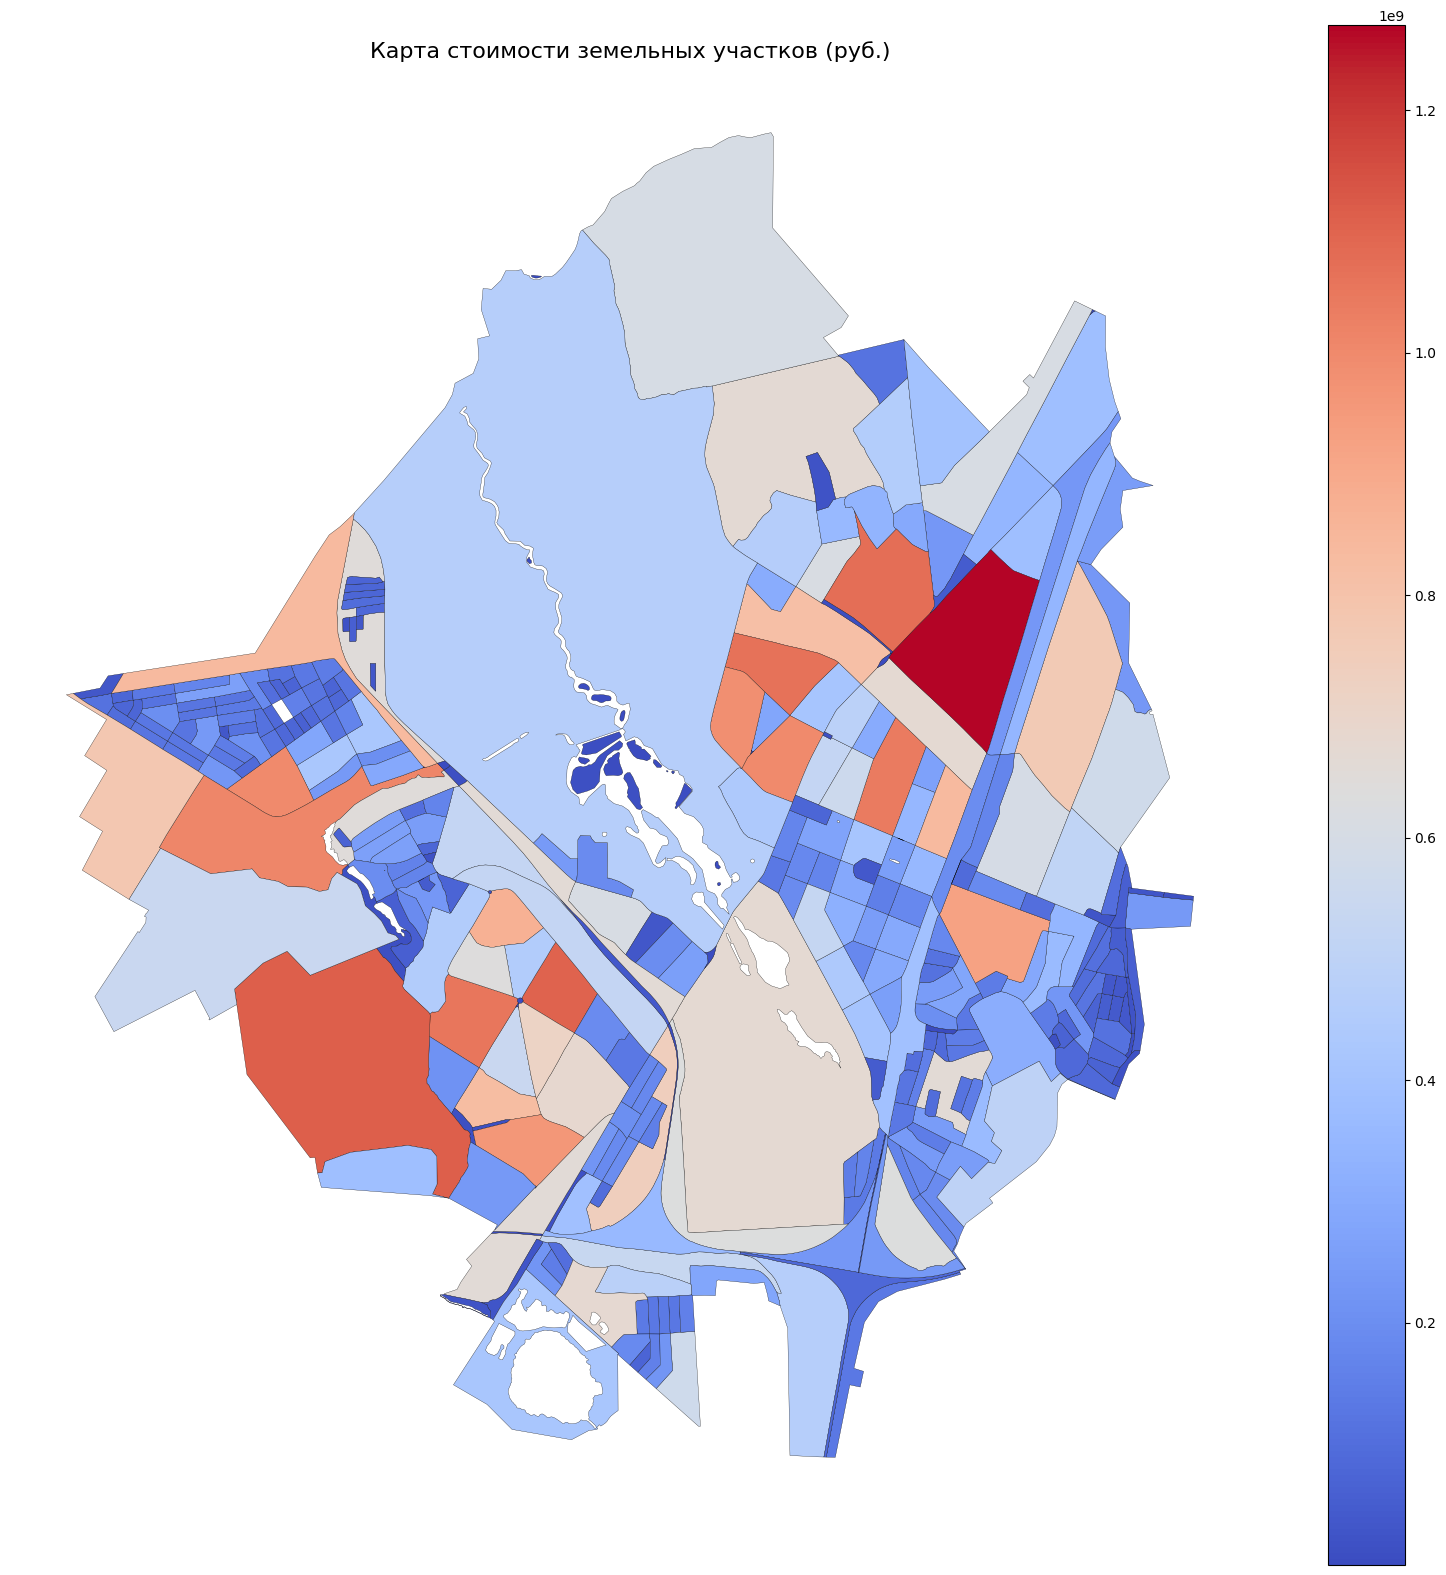

In [9]:
import matplotlib.pyplot as plt

blocks_clean.plot(
    column='land_value',
    legend=True,
    figsize=(20,20),
    cmap='coolwarm',
    edgecolor='black',   # <-- цвет границы
    linewidth=0.2        # <-- толщина границы
).set_axis_off()
plt.title('Карта стоимости земельных участков (руб.)', fontsize=16)

plt.show()

In [10]:
blocks_clean["id"] = blocks_clean.index

In [11]:
# blocks_clean.explore()

/var/folders/h8/0wmx2zx90bn60jw8zc1r4qjc0000gn/T/ipykernel_13856/1807181840.py:8: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  blocks_clean.loc[blocks_clean["id"]==87].centroid.plot(


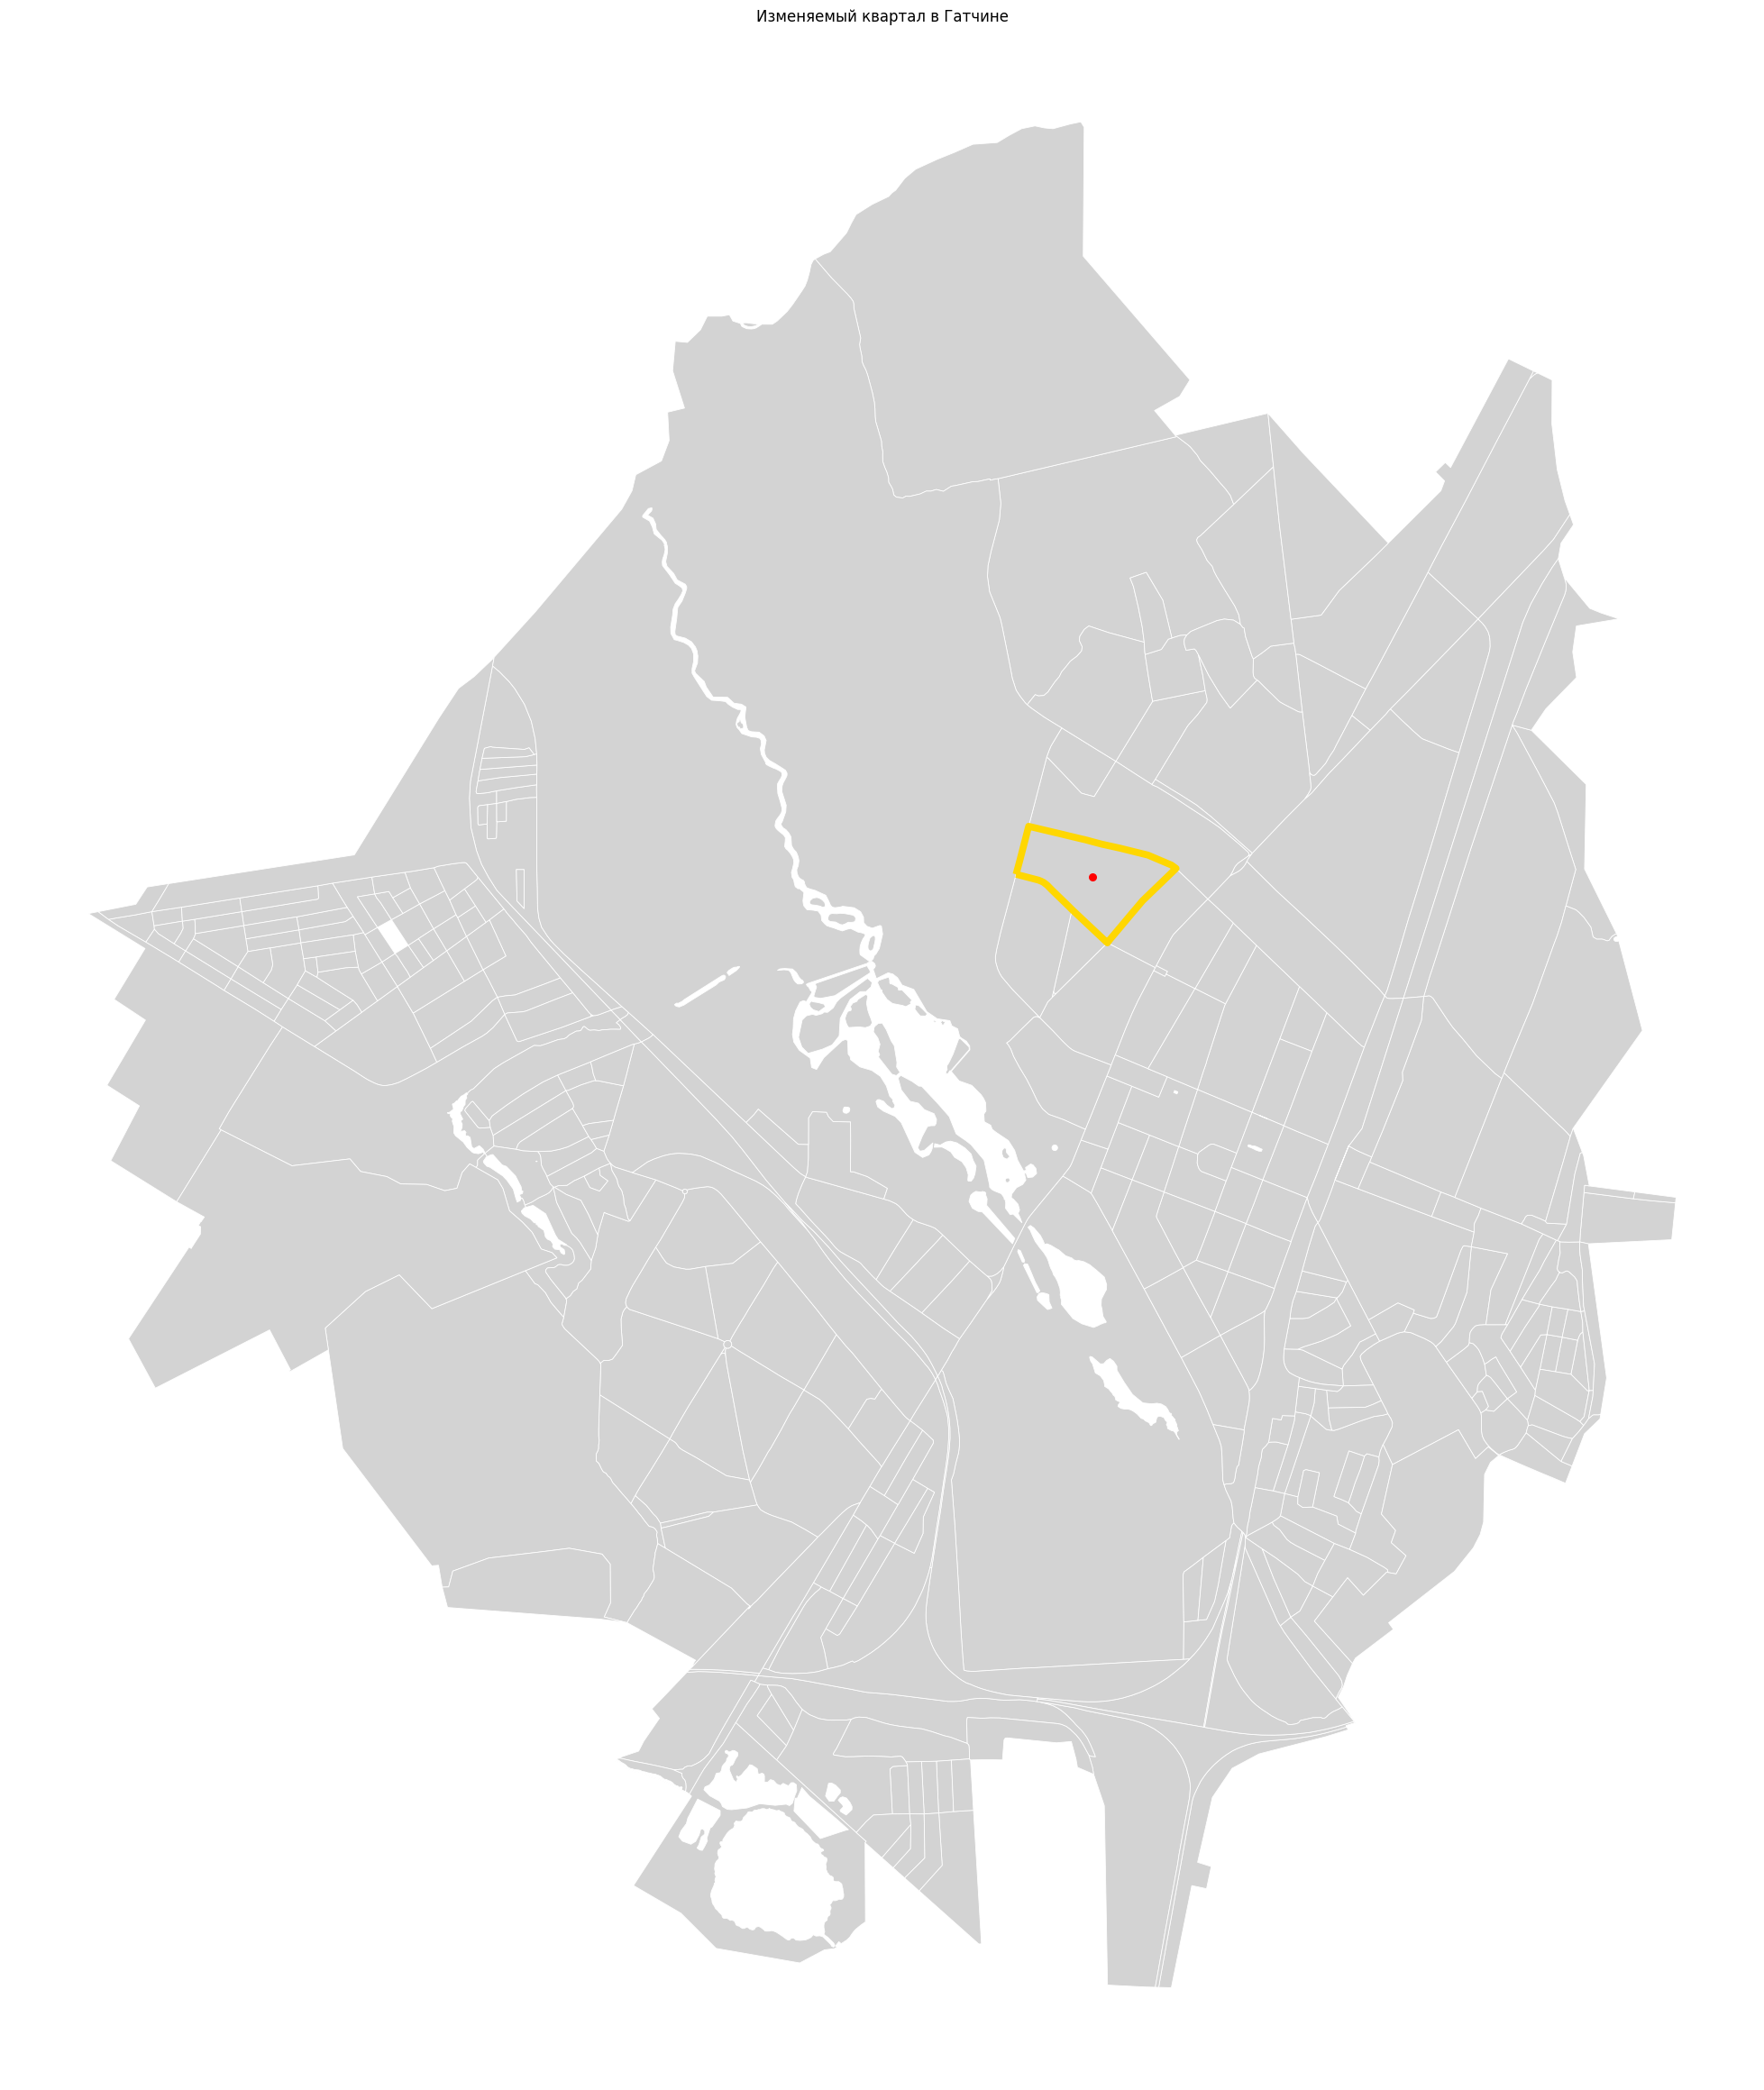

In [12]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(25, 35))
blocks_clean.plot(ax=ax, color="lightgrey", edgecolor="white", linewidth=0.6)  # фон
blocks_clean.loc[blocks_clean["id"]==87].plot(
    ax=ax, color="none", edgecolor="gold", linewidth=5.5
)
blocks_clean.loc[blocks_clean["id"]==87].centroid.plot(
     ax=ax, color="red", markersize=30, zorder=3
 )

ax.set_title("Изменяемый квартал в Гатчине")
ax.axis("off")
plt.show()

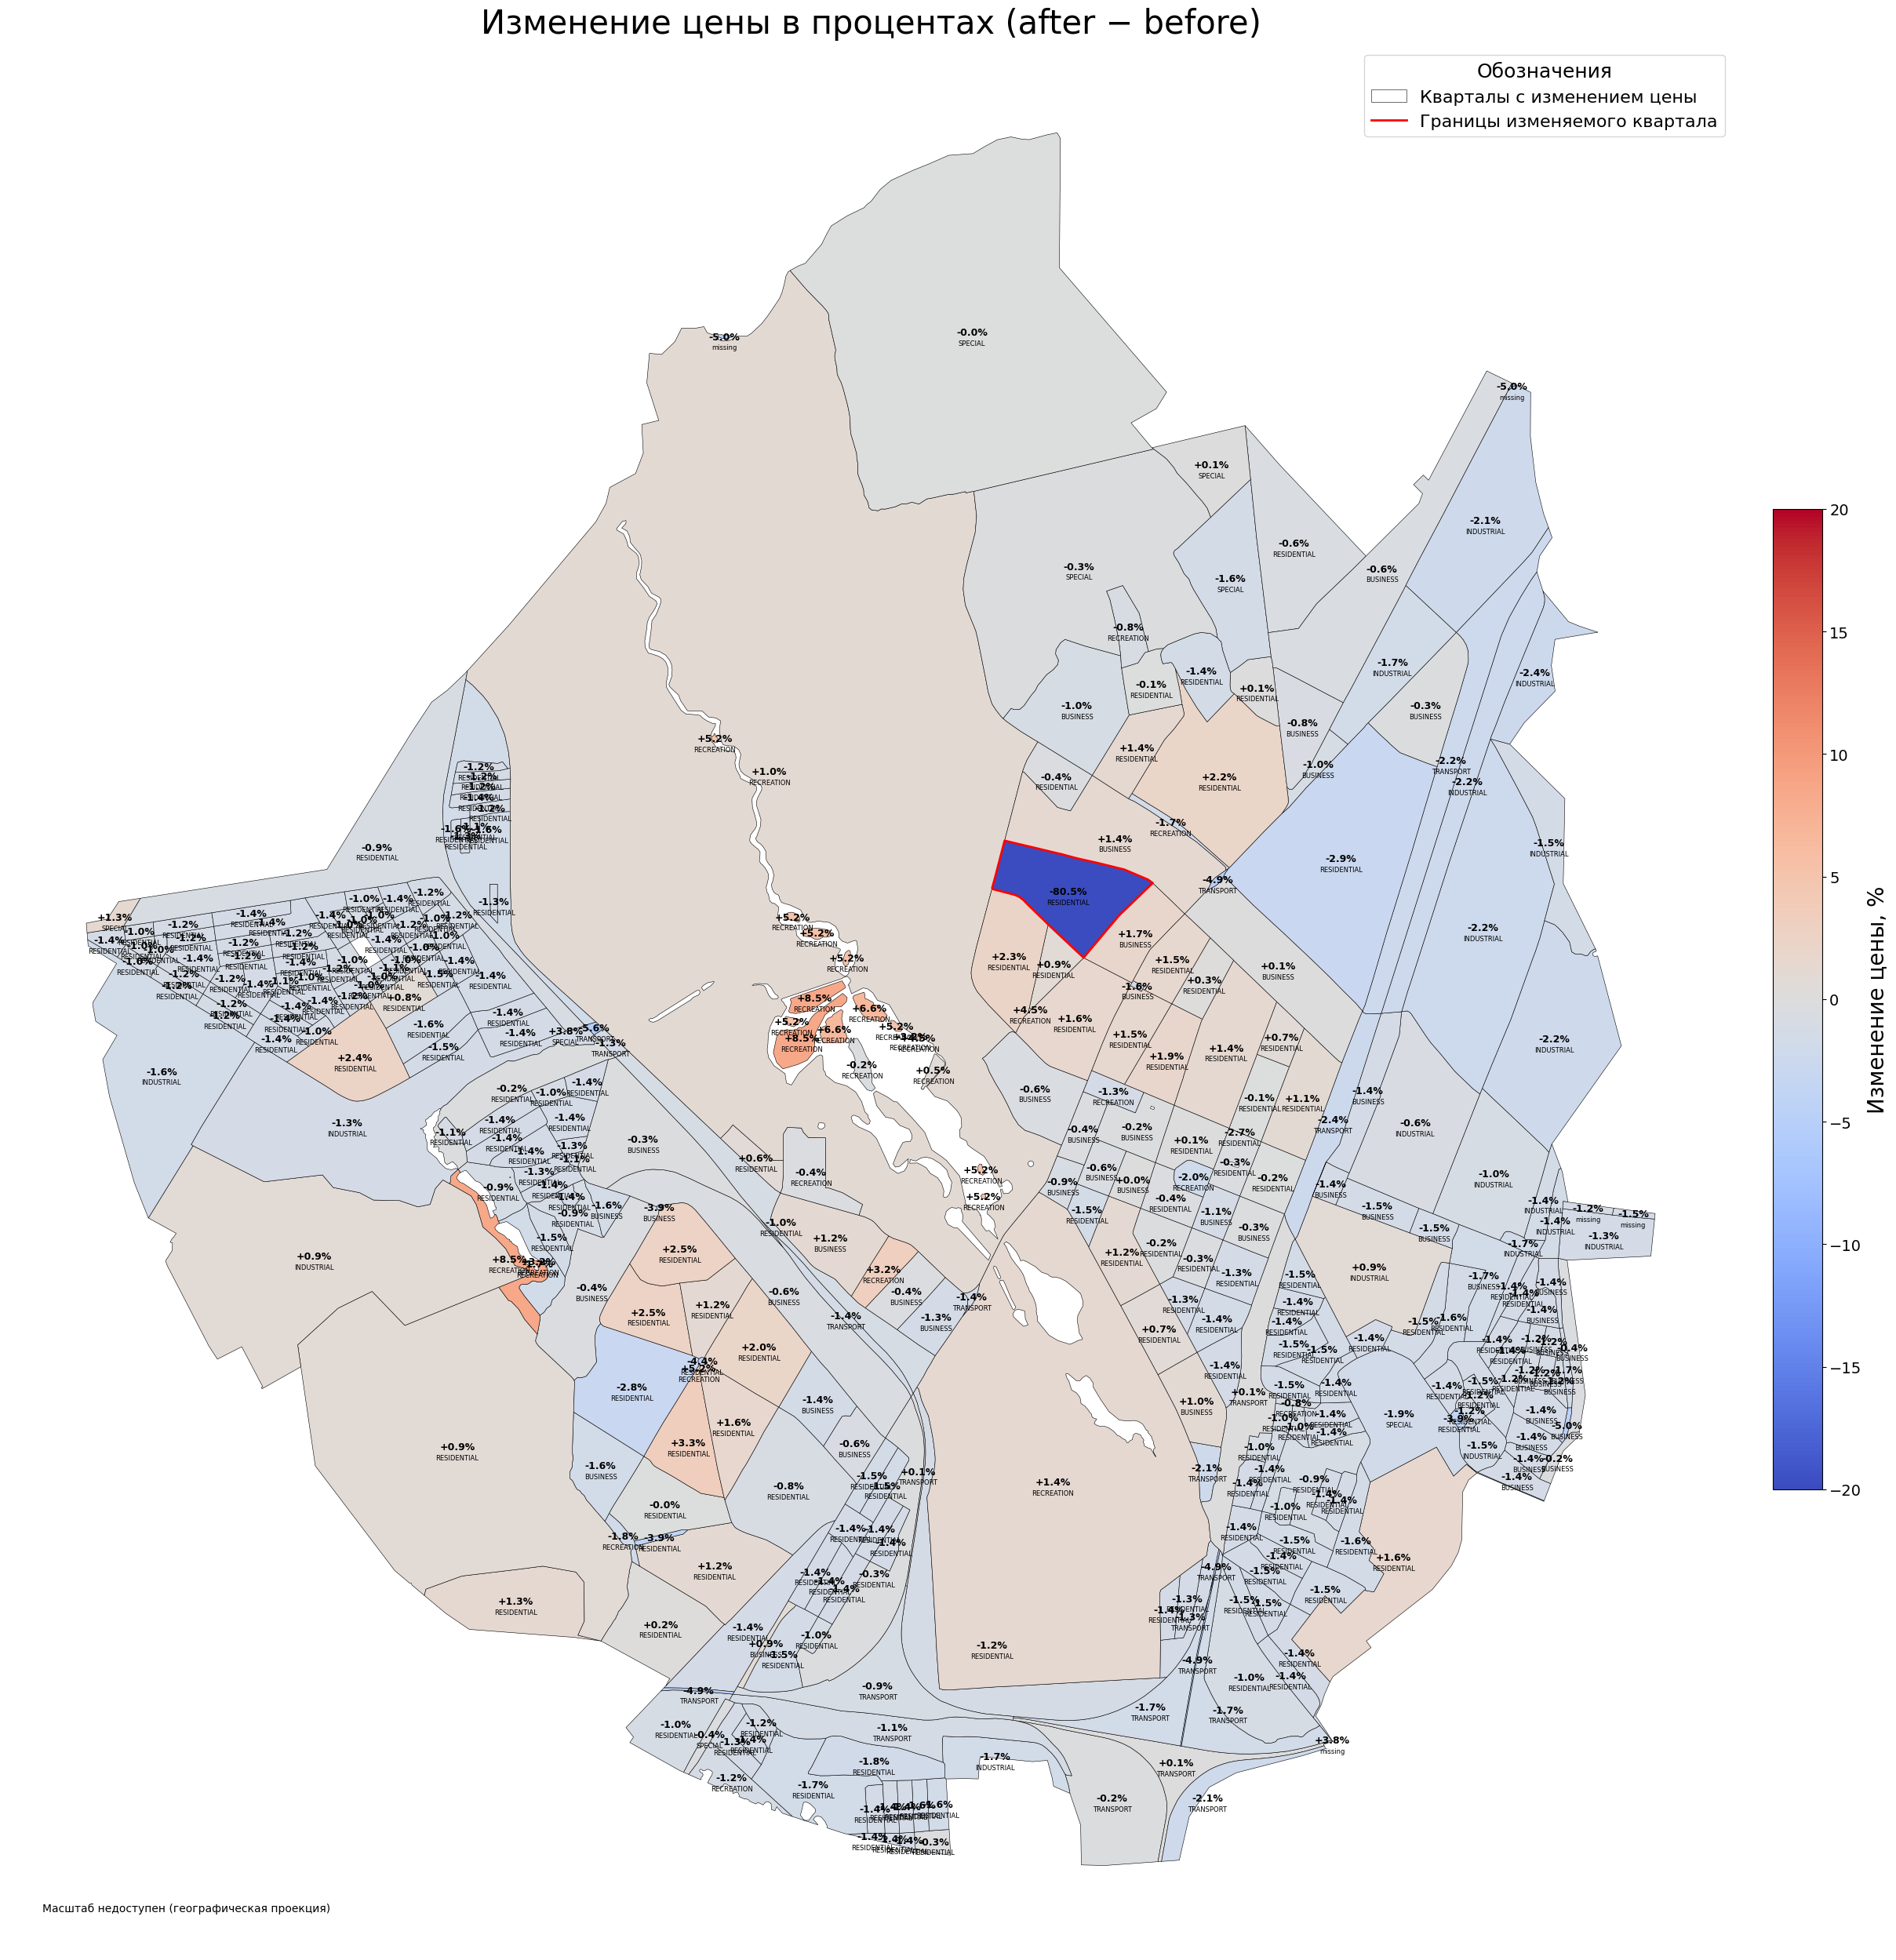


Статистика по кварталам в контексте (|Δ₽| > 1e-09):

Изменяемый квартал:
index | land_use | до (₽) → после (₽) | Δ₽ | Δ%
87 | RESIDENTIAL | 1 044 985 582 ₽ → 204 203 057 ₽ | -840 782 525 ₽ | -80.5%

Кварталы в границах проекта:
Нет кварталов проекта с изменениями выше порога.

Кварталы в контексте:
index | land_use | до (₽) → после (₽) | Δ₽ | Δ%
311 | RESIDENTIAL | 558 068 634 ₽ → 556 360 738 ₽ | -1 707 896 ₽ | -0.3%
248 | TRANSPORT | 463 610 653 ₽ → 462 661 846 ₽ | -948 807 ₽ | -0.2%
298 | TRANSPORT | 90 038 010 ₽ → 90 119 286 ₽ | +81 276 ₽ | +0.1%
115 | RESIDENTIAL | 129 175 469 ₽ → 127 108 601 ₽ | -2 066 868 ₽ | -1.6%
317 | RESIDENTIAL | 157 610 237 ₽ → 155 124 501 ₽ | -2 485 735 ₽ | -1.6%
318 | INDUSTRIAL | 283 475 839 ₽ → 278 647 666 ₽ | -4 828 173 ₽ | -1.7%
225 | TRANSPORT | 237 712 832 ₽ → 233 759 373 ₽ | -3 953 459 ₽ | -1.7%
299 | TRANSPORT | 3 887 664 ₽ → 3 698 518 ₽ | -189 146 ₽ | -4.9%
5 | TRANSPORT | 134 459 896 ₽ → 132 667 343 ₽ | -1 792 553 ₽ | -1.3%
113 | RESIDENTIAL | 

In [13]:
from urbanomy.methods.land_value_modeling import (
    ScenarioTEPModifier,
    plot_scenario_impact,
)
# Все снесли - ничего не осталось
blocks_after = blocks_clean
changes = {
        # Структура использования территории
        "residential": 0.0,
        "business": 0.0,
        "recreation": 0.0,
        "industrial": 0.0,
        "transport": 0.0,
        "special": 0.0,
        "agriculture": 0.0,
        "share": 1.0,

    
    "footprint_area": 0.0,   
    "build_floor_area": 0.0,  
    "living_area": 0.0,      
    "non_living_area": 0.0,  
    "population": 0.0,                

    
    "fsi": 0.0,                         
    "gsi": 0.0,                        
    "l": 0.0,                          
                     

        
        "morphotype": "low-rise non-residential",
}

target_idx = 87

modifier = ScenarioTEPModifier(blocks_after)
blocks_before = modifier.apply(target_idx, changes)

scenario_result = plot_scenario_impact(
    blocks_before=blocks_after,
    blocks_after=blocks_before,
    orig_features=numeric_feats+cat_features,
    categorical_features=cat_features,
    model=model,
    target_idx=target_idx,
    figsize=(25, 35),
)

In [14]:
# blocks_after.to_file('./data/test/gatchina_RESIDENTIAL.geojson', driver='GeoJSON')

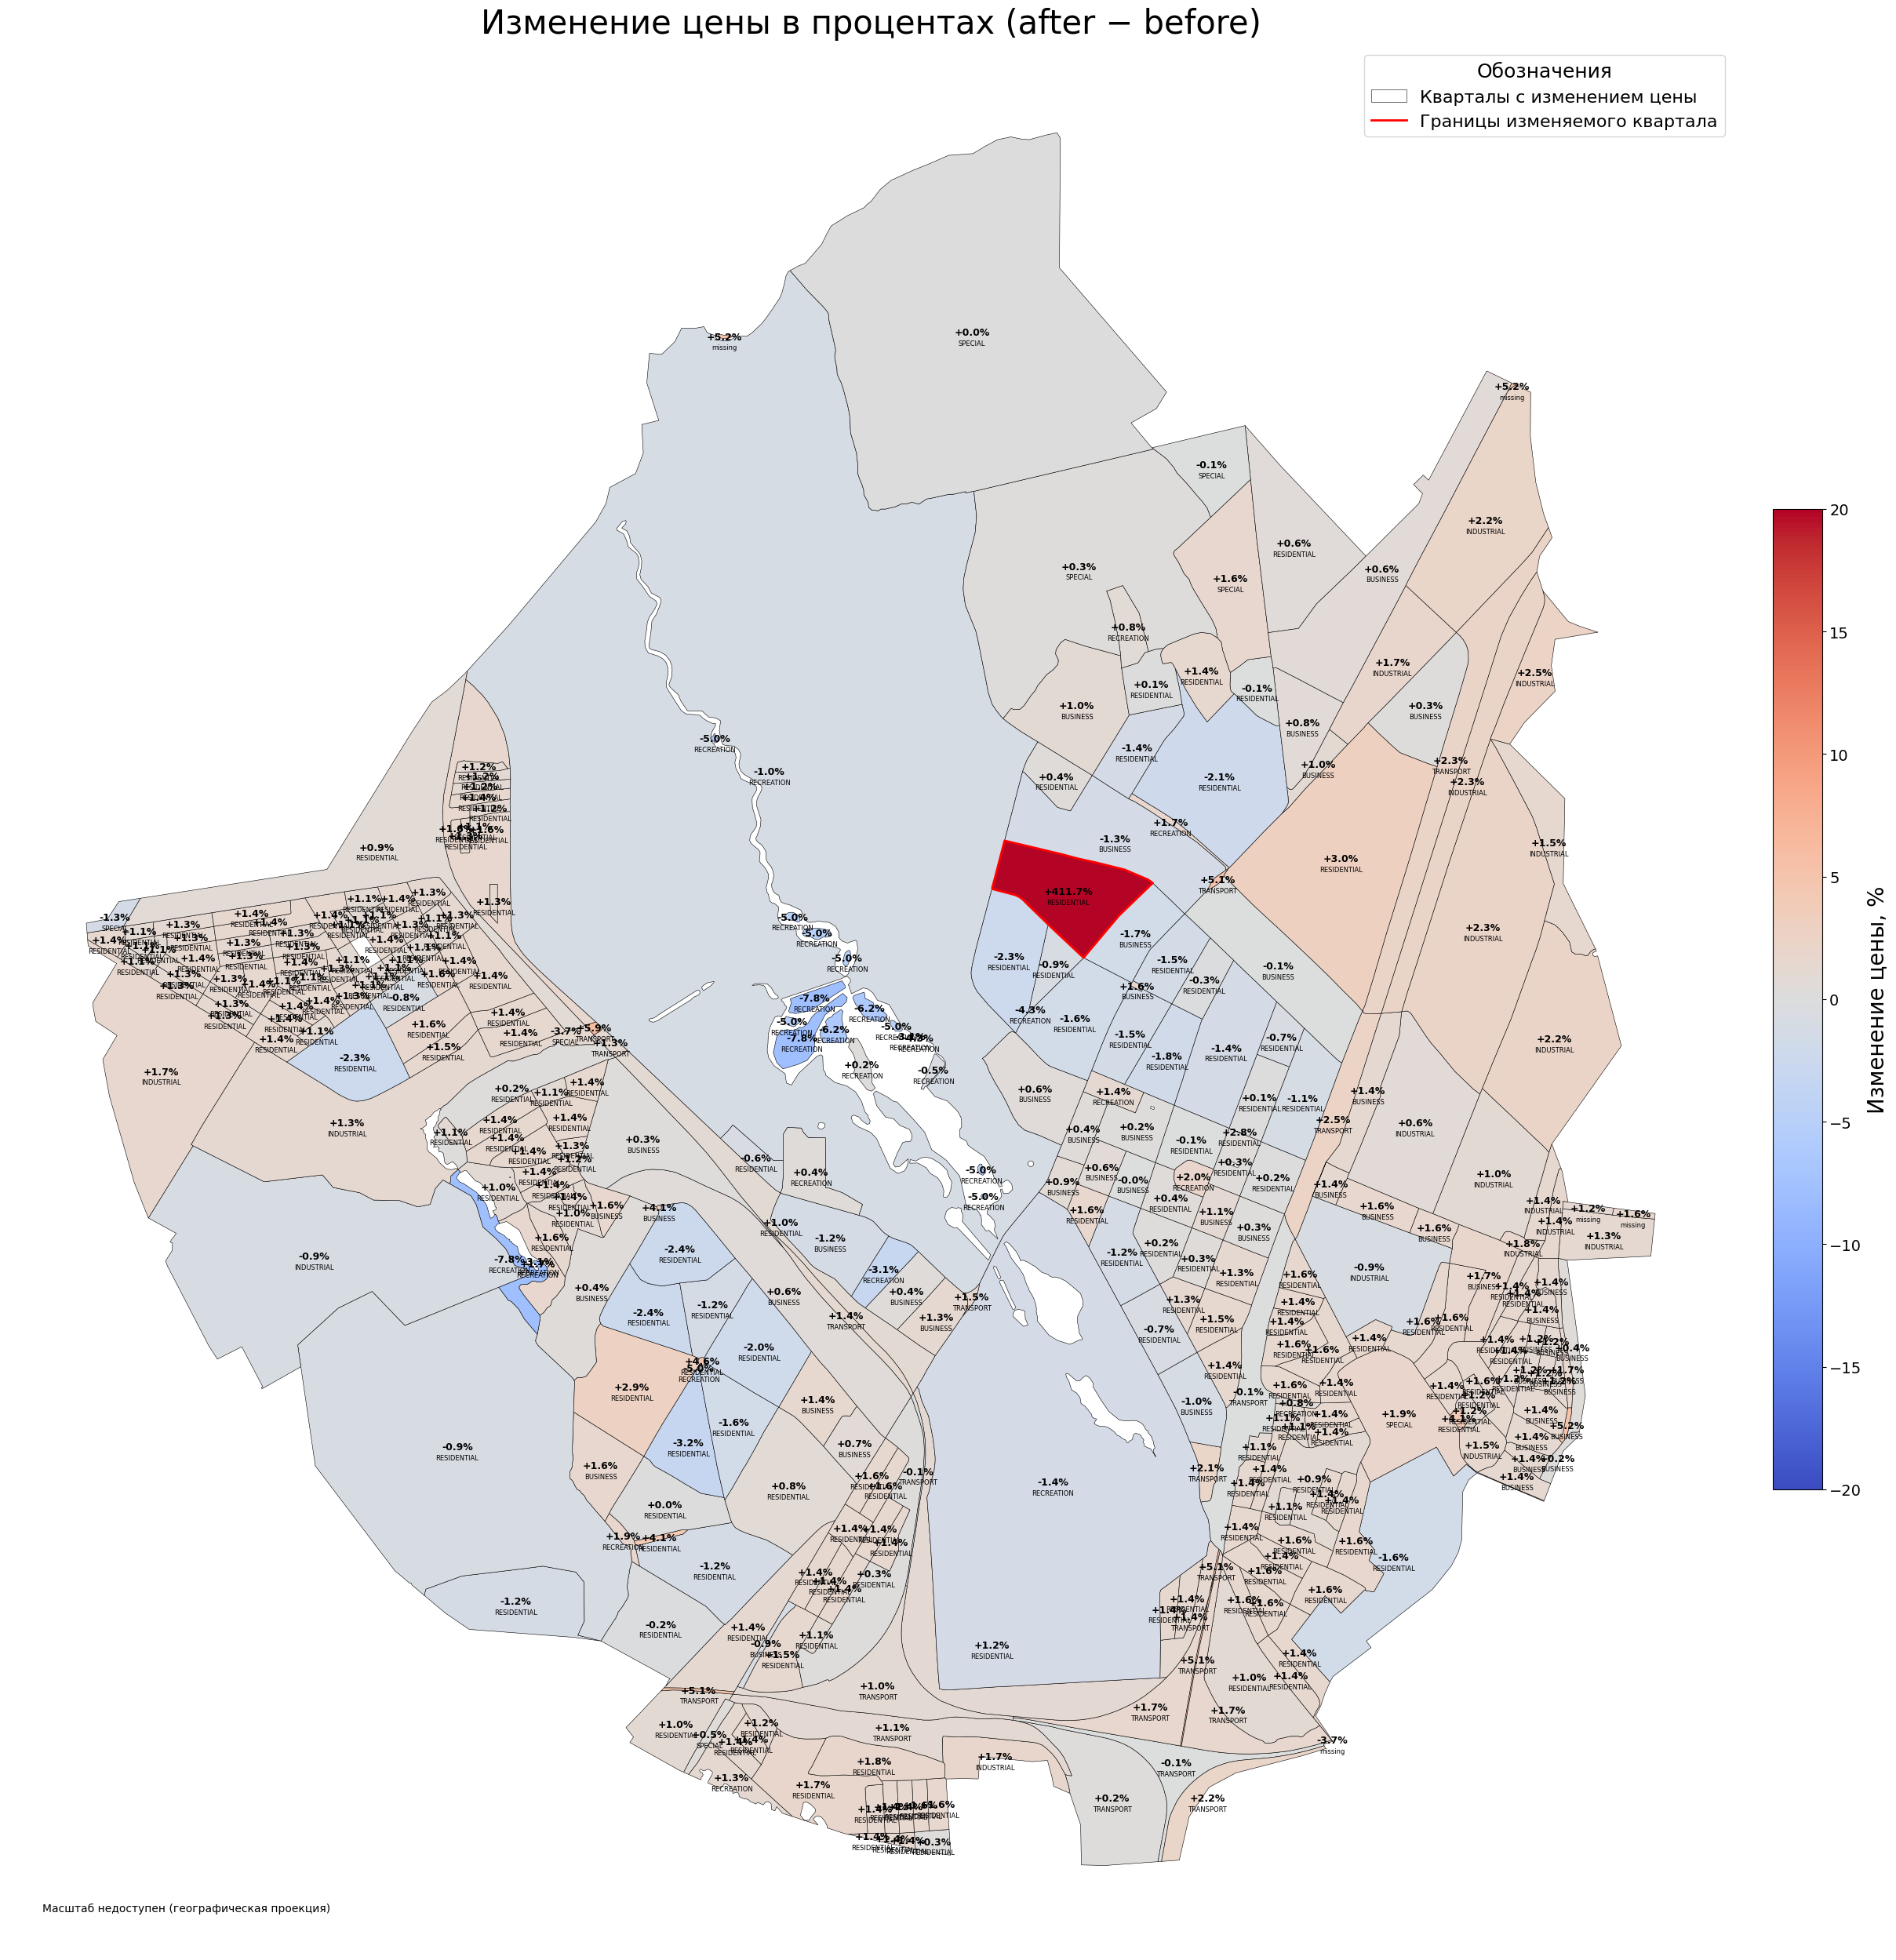


Статистика по кварталам в контексте (|Δ₽| > 1e-09):

Изменяемый квартал:
index | land_use | до (₽) → после (₽) | Δ₽ | Δ%
87 | RESIDENTIAL | 204 203 057 ₽ → 1 044 985 582 ₽ | +840 782 525 ₽ | +411.7%

Кварталы в границах проекта:
Нет кварталов проекта с изменениями выше порога.

Кварталы в контексте:
index | land_use | до (₽) → после (₽) | Δ₽ | Δ%
311 | RESIDENTIAL | 556 360 738 ₽ → 558 068 634 ₽ | +1 707 896 ₽ | +0.3%
248 | TRANSPORT | 462 661 846 ₽ → 463 610 653 ₽ | +948 807 ₽ | +0.2%
298 | TRANSPORT | 90 119 286 ₽ → 90 038 010 ₽ | -81 276 ₽ | -0.1%
115 | RESIDENTIAL | 127 108 601 ₽ → 129 175 469 ₽ | +2 066 868 ₽ | +1.6%
317 | RESIDENTIAL | 155 124 501 ₽ → 157 610 237 ₽ | +2 485 735 ₽ | +1.6%
318 | INDUSTRIAL | 278 647 666 ₽ → 283 475 839 ₽ | +4 828 173 ₽ | +1.7%
225 | TRANSPORT | 233 759 373 ₽ → 237 712 832 ₽ | +3 953 459 ₽ | +1.7%
299 | TRANSPORT | 3 698 518 ₽ → 3 887 664 ₽ | +189 146 ₽ | +5.1%
5 | TRANSPORT | 132 667 343 ₽ → 134 459 896 ₽ | +1 792 553 ₽ | +1.4%
113 | RESIDENTIAL |

In [15]:
# Теперь все вернули обратно!
scenario_result = plot_scenario_impact(
    blocks_before=blocks_before, # поменял местами датафреймы!
    blocks_after=blocks_after,
    orig_features=numeric_feats+cat_features,
    categorical_features=cat_features,
    model=model,
    target_idx=target_idx,
    figsize=(25, 35),
)

# Оптимизация агентами!

# **Инвестиционная** привлекактельтность 

In [16]:
blocks_after = blocks_after.copy()
blocks_after["is_project"] = False
blocks_after.loc[blocks_after["id"] == target_idx, "is_project"] = True


In [17]:
from blocksnet.enums import LandUse

benchmarks_ru = {
    LandUse.RESIDENTIAL: {
        "cost_build": 70_000,       # руб/м2 (жильё, СПб/ЛО)
        "price_sale": 160_000,      # руб/м2 (средний класс)
        "construction_years": 3,
        "sale_years": 4,
        "opex_rate": 900,           # эксплуатация жилого фонда
    },
    LandUse.BUSINESS: {
        "cost_build": 85_000,       # офисно-деловая застройка
        "rent_annual": 28_000,      # руб/м2/год
        "rent_years": 12,
        "construction_years": 4,
        "opex_rate": 1_400,
    },
    LandUse.RECREATION: {
        "cost_build": 40_000,       # парки, культура, спорт
        "rent_annual": 7_500,       # чаще косвенные доходы/аренда
        "rent_years": 15,
        "construction_years": 3,
        "opex_rate": 650,
    },
    LandUse.SPECIAL: {              # образование/медицина, гос объект
        "cost_build": 55_000,
        "rent_annual": 12_500,
        "rent_years": 15,
        "construction_years": 3,
        "opex_rate": 1_700,
    },
    LandUse.INDUSTRIAL: {
        "cost_build": 45_000,       # промка (ангар, лайт-индастри)
        "rent_annual": 15_500,
        "rent_years": 12,
        "construction_years": 3,
        "opex_rate": 750,
    },
    LandUse.AGRICULTURE: {
        "cost_build": 28_000,
        "rent_annual": 7_200,
        "rent_years": 15,
        "construction_years": 3,
        "opex_rate": 350,
    },
    LandUse.TRANSPORT: {
        "cost_build": 30_000,       # склад, логистика, хабы
        "rent_annual": 7_000,
        "rent_years": 15,
        "construction_years": 3,
        "opex_rate": 650,
    },
}

In [18]:
from urbanomy.methods.investment_potential import prepare_investment_input


potential_df = pd.read_csv("./data/gatchina/land_use_potentials.csv")

investment_input = prepare_investment_input(
    gdf = blocks_after,
    project_potential = potential_df,
)

investment_input.head()

2026-02-17 18:13:48.467 | WARNING  | urbanomy.utils.investment_input:prepare_investment_input:452 - prepare_investment_input: колонка 'land_value_before' не найдена; значения скопированы из 'land_value'.


,land_use,land_value,land_value_before,site_area,living_area,non_living_area,build_floor_area,share,spatial_potential
0,LandUse.RESIDENTIAL,1.066619e+09,1.066619e+09,705080.041579,132192.815395,58395.681287,190588.496682,0.690324,0.0


In [19]:
from urbanomy.methods.investment_potential import InvestmentAttractivenessAnalyzer

an = InvestmentAttractivenessAnalyzer(benchmarks=benchmarks_ru)
summary = an.calculate_investment_metrics(investment_input, discount_rate=0.18)
summary

Project totals:
 • Land area:          705,080.04
 • Built area:         190,588.50
 • Land value:         1,066,618,958.46
 • Construction cost:  13,341,194,767.72
 • Investment need:    14,407,813,726.18
 • Spatial potential:  0.00
 • Project NPV:        1,920,793,661.79
 • Project IRR:        0.23
 • Project ROI:        3.79
 • Project PP (yrs):   6.30
 • Project EI:         70.72
 • Project INV score:  42.43


,land_use,land_area,land_value_before,built_area,land_value,construction_cost,investment_need,NPV,IRR,ROI,PP_years,EI,spatial_potential,INV
0,LandUse.RESIDENTIAL,705080.04,1.066619e+09,190588.5,1.066619e+09,1.334119e+10,1.440781e+10,1.920794e+09,0.23,3.79,6.3,70.72,0.0,42.43


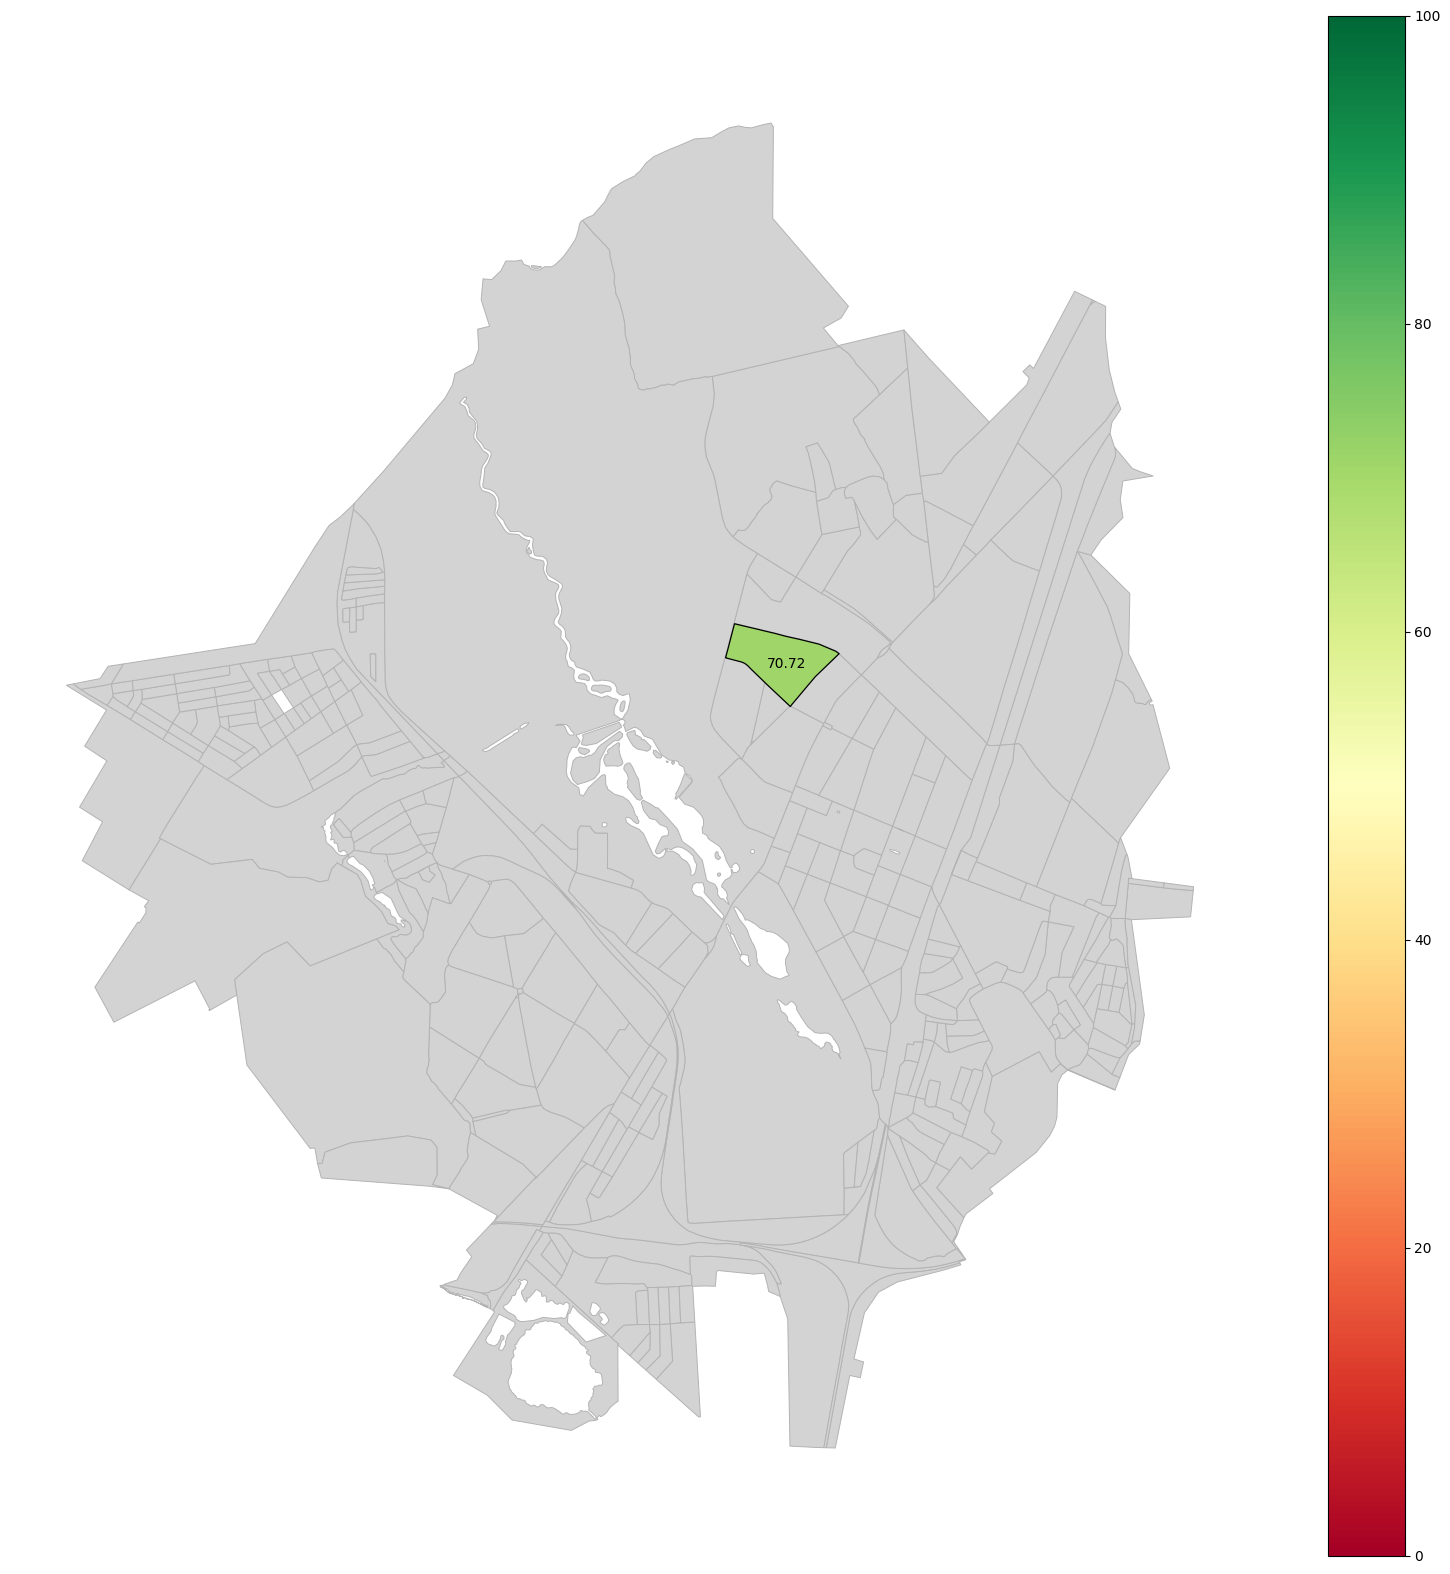

In [20]:
# 1) кладём summary на нужный индекс
summary_idxed = summary.copy()
summary_idxed.index = [target_idx]  # если одна строка; иначе set_index по id

# 2) собираем слой
scn = blocks_after[["geometry"]].join(summary_idxed, how="left")
scn["is_project"] = scn.index == target_idx

column = "EI"
vmin, vmax = 0, 100

fig, ax = plt.subplots(figsize=(20, 20))
scn.loc[~scn["is_project"]].plot(ax=ax, color="lightgrey", edgecolor="0.7", linewidth=0.7)

scn_proj = scn.loc[scn["is_project"]]
if len(scn_proj):
    scn_proj.plot(
        ax=ax,
        column=column,
        cmap="RdYlGn",
        legend=True,
        edgecolor="black",
        linewidth=0.9,
        vmin=vmin,
        vmax=vmax,
    )
    for _, row in scn_proj.dropna(subset=[column]).iterrows():
        x, y = row.geometry.representative_point().coords[0]
        ax.text(x, y, f"{row[column]:.2f}", ha="center", va="center", fontsize=10, color="black")

ax.set_axis_off()
plt.show()

In [21]:
from urbanomy.methods.socio_economic_indicators.sei_calculate import SEREstimator

deafaut_cfg = {
    "population": 300_000,
}

est = SEREstimator(deafaut_cfg) # or use project_cfg
result = est.compute(scn, pretty=True)
result

,indicator,delta_total
0,Объём инвестиций в основной капитал на душу на...,44 471
1,Валовый региональный продукт на душу населения,21 282
2,Доходы бюджета территории,5 569 948 816
3,Средний уровень заработной платы,0.0000
4,Износ основного фонда (тыс. руб.),380 224


## Оптимизация пустого района

In [22]:
from urbanomy.methods.land_value_modeling.ga_mc_optimizer import DistrictProblem
# теперь оптимизируем пустой район генетикой!
target_idx = 87
blocks_after.iloc[86]
site_area = float(blocks_after["site_area"].iloc[86])
floors_neighborhood_avg = blocks_after['build_floor_area'].mean() 


In [ ]:
problem = DistrictProblem(
    blocks=blocks_after,
    target_idx=target_idx,
    model=model,
    benchmarks=benchmarks_ru,
    potential_df=potential_df,
    
constraints = {
    "footprint_area": {"type": "float", "min": 0.0, "max": 0.08 * site_area},
    "l": {"type": "float", "min": 1.0, "max": 10.0},
    "mxi": {"type": "float", "min": 0.0, "max": 1.0},



    "residential": {"type": "float", "min": 0.0, "max": 1.0},
    "business": {"type": "float", "min": 0.0, "max": 1.0},
    "recreation": {"type": "float", "min": 0.0, "max": 1.0},
    "industrial": {"type": "float", "min": 0.0, "max": 1.0},
    "transport": {"type": "float", "min": 0.0, "max": 1.0},
    "special": {"type": "float", "min": 0.0, "max": 1.0},
    "agriculture": {"type": "float", "min": 0.0, "max": 1.0},
},
    
    estimator_kwargs={
        "orig_features": numeric_feats+cat_features,
        "categorical_features": cat_features,
    }
)

In [ ]:
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.optimize import minimize

algorithm = NSGA2(
    pop_size=50,
    eliminate_duplicates=True,
)

res = minimize(
    problem,
    algorithm,
    ('n_gen', 10),
    seed=42,
    verbose=True,
)


n_gen  |  n_eval  | n_nds  |      eps      |   indicator  
     1 |       50 |      3 |             - |             -
     2 |      100 |      4 |  0.0680891945 |         nadir
     3 |      150 |      4 |  0.0304642511 |         ideal
     4 |      200 |      8 |  0.3630769946 |         ideal


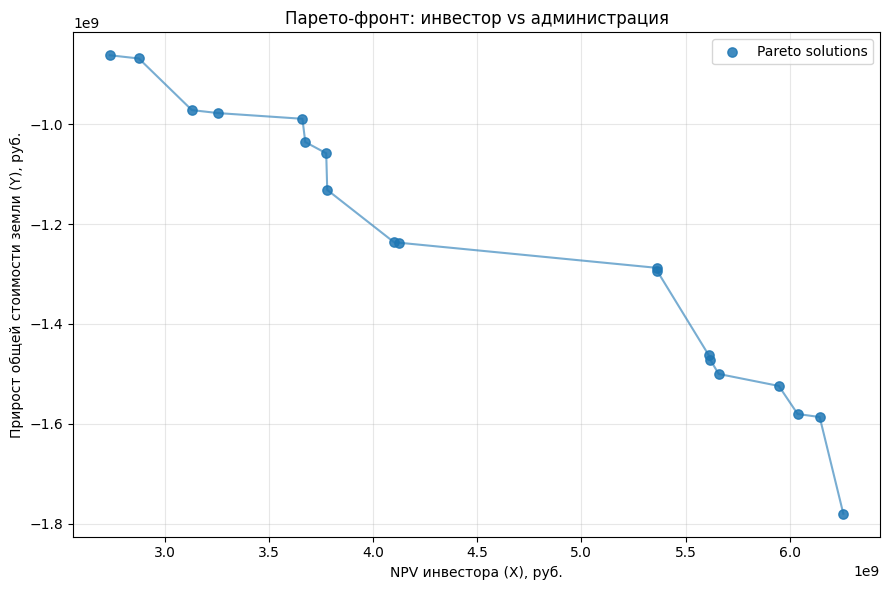

In [36]:
import numpy as np
import matplotlib.pyplot as plt


optimizer = problem

# 1) Базовая стоимость земли "до" (для расчета прироста)
baseline_land_value = optimizer.evaluate_catboost(
    geonome=optimizer.blocks,
    model=optimizer.model,
    orig_features=optimizer.estimator_kwargs["orig_features"],
    cat_features=optimizer.estimator_kwargs["categorical_features"],
    radius_list=None,  # возьмет дефолтные RADIUS_LIST внутри evaluate_catboost
)

# 2) Извлекаем цели из Pareto-решений
# В _evaluate у вас:
# F[:,0] = -land_value
# F[:,1] = -investment_potential (NPV)
F = res.F

land_value_total = -F[:, 0]                 # общая стоимость земли после сценария
admin_gain = land_value_total - baseline_land_value   # прирост для администрации (Y)
investor_npv = -F[:, 1]                     # NPV для инвестора (X)

# 3) Сортировка по X для красивой линии фронта
order = np.argsort(investor_npv)
x = investor_npv[order]
y = admin_gain[order]

# 4) График Парето-фронта
plt.figure(figsize=(9, 6))
plt.scatter(x, y, s=45, alpha=0.85, label="Pareto solutions")
plt.plot(x, y, alpha=0.6)

plt.xlabel("NPV инвестора (X), руб.")
plt.ylabel("Прирост общей стоимости земли (Y), руб.")
plt.title("Парето-фронт: инвестор vs администрация")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [37]:
print("Лучшие решения (переменные):\n", res.X) # Массив решений на фронте Парето
print("Значения целевых функций:\n", -res.F)


Лучшие решения (переменные):
 [[4.34322038e+04 9.81063584e+00 4.14727152e-01 9.32510276e-01
  2.52796283e-01 1.05113429e-02 4.09980317e-02 7.94005602e-01
  5.45051175e-01 2.35802779e-01]
 [2.80181465e+04 9.55642876e+00 6.79034794e-01 9.08032412e-01
  2.50624949e-01 2.54404911e-02 4.09980317e-02 7.51241497e-01
  5.23612321e-01 2.36328494e-01]
 [3.14850439e+04 9.82069511e+00 3.15878298e-01 9.32180543e-01
  2.55515806e-01 2.51254640e-02 4.09980317e-02 8.47371184e-01
  5.43801059e-01 2.35802779e-01]
 [4.57065974e+04 9.38806053e+00 3.15726320e-01 9.32180543e-01
  2.54845832e-01 2.51254640e-02 4.09980317e-02 7.55106048e-01
  5.50702611e-01 2.36317869e-01]
 [3.08002394e+04 9.82069511e+00 3.56852154e-01 9.32180543e-01
  2.55515806e-01 2.51254640e-02 4.09980317e-02 8.44213993e-01
  5.43801059e-01 2.35802779e-01]
 [3.15601350e+04 9.55642876e+00 6.38060938e-01 9.08032412e-01
  2.50624949e-01 1.16892326e-02 4.09980317e-02 7.54398689e-01
  5.23612321e-01 2.36328494e-01]
 [4.37014715e+04 9.38806053e

In [38]:
len(res.opt)

19

In [28]:
# for i, opt in enumerate(res.opt):
#     params = {name: opt.X[j] for j, name in enumerate(problem.var_names)}
#     params = problem._repair_genome(params)
#     plot_scenario_impact(
#         blocks_before=blocks_after,
#         blocks_after=ScenarioTEPModifier(blocks_after).apply(target_idx, params),
#         orig_features=numeric_feats+cat_features,
#         categorical_features=cat_features,
#         model=model,
#         target_idx=target_idx,
#         figsize=(25, 35),
#     )
#     print(f"Решение {i}:")
#     print("Переменные (геном):", opt.X)
#     print("Целевые функции:", -opt.F)
#     print("-" * 30)

In [40]:
import numpy as np

# т.к. F минимизируется, а ты пишешь F[:,0] = -land_value
idx_city = np.argmin(res.F[:, 0])   # максимум land_value
params_optimal = {p: res.X[idx_city][i] for i, p in enumerate(problem.constraints.keys())}
params_optimal

{'footprint_area': np.float64(38840.570199287875),
 'l': np.float64(6.246398408052664),
 'mxi': np.float64(0.7040171741780814),
 'residential': np.float64(0.932287134640661),
 'business': np.float64(0.2545958442089354),
 'recreation': np.float64(0.09145486069425694),
 'industrial': np.float64(0.033701793001602975),
 'transport': np.float64(0.8399947521732919),
 'special': np.float64(0.4455208571630145),
 'agriculture': np.float64(0.25325257132257295)}

In [41]:
params_repaired = problem._repair_genome(params_optimal)
params_repaired

{'footprint_area': 38840.570199287875,
 'l': 6.246398408052664,
 'mxi': 0.7040171741780814,
 'residential': 0.3270255996642443,
 'business': 0.08930656182072377,
 'recreation': 0.0320803318521359,
 'industrial': 0.011821839706452127,
 'transport': 0.29465148379438794,
 'special': 0.15627881160541815,
 'agriculture': 0.08883537155663769,
 'share': 0.3270255996642443,
 'land_use': <LandUse.RESIDENTIAL: 'residential'>,
 'build_floor_area': 242613.67586068952,
 'living_area': 170804.19449639964,
 'non_living_area': 71809.48136428988,
 'population': 8540.209724819983,
 'fsi': 0.344093807161781,
 'gsi': 0.055086753146931185}

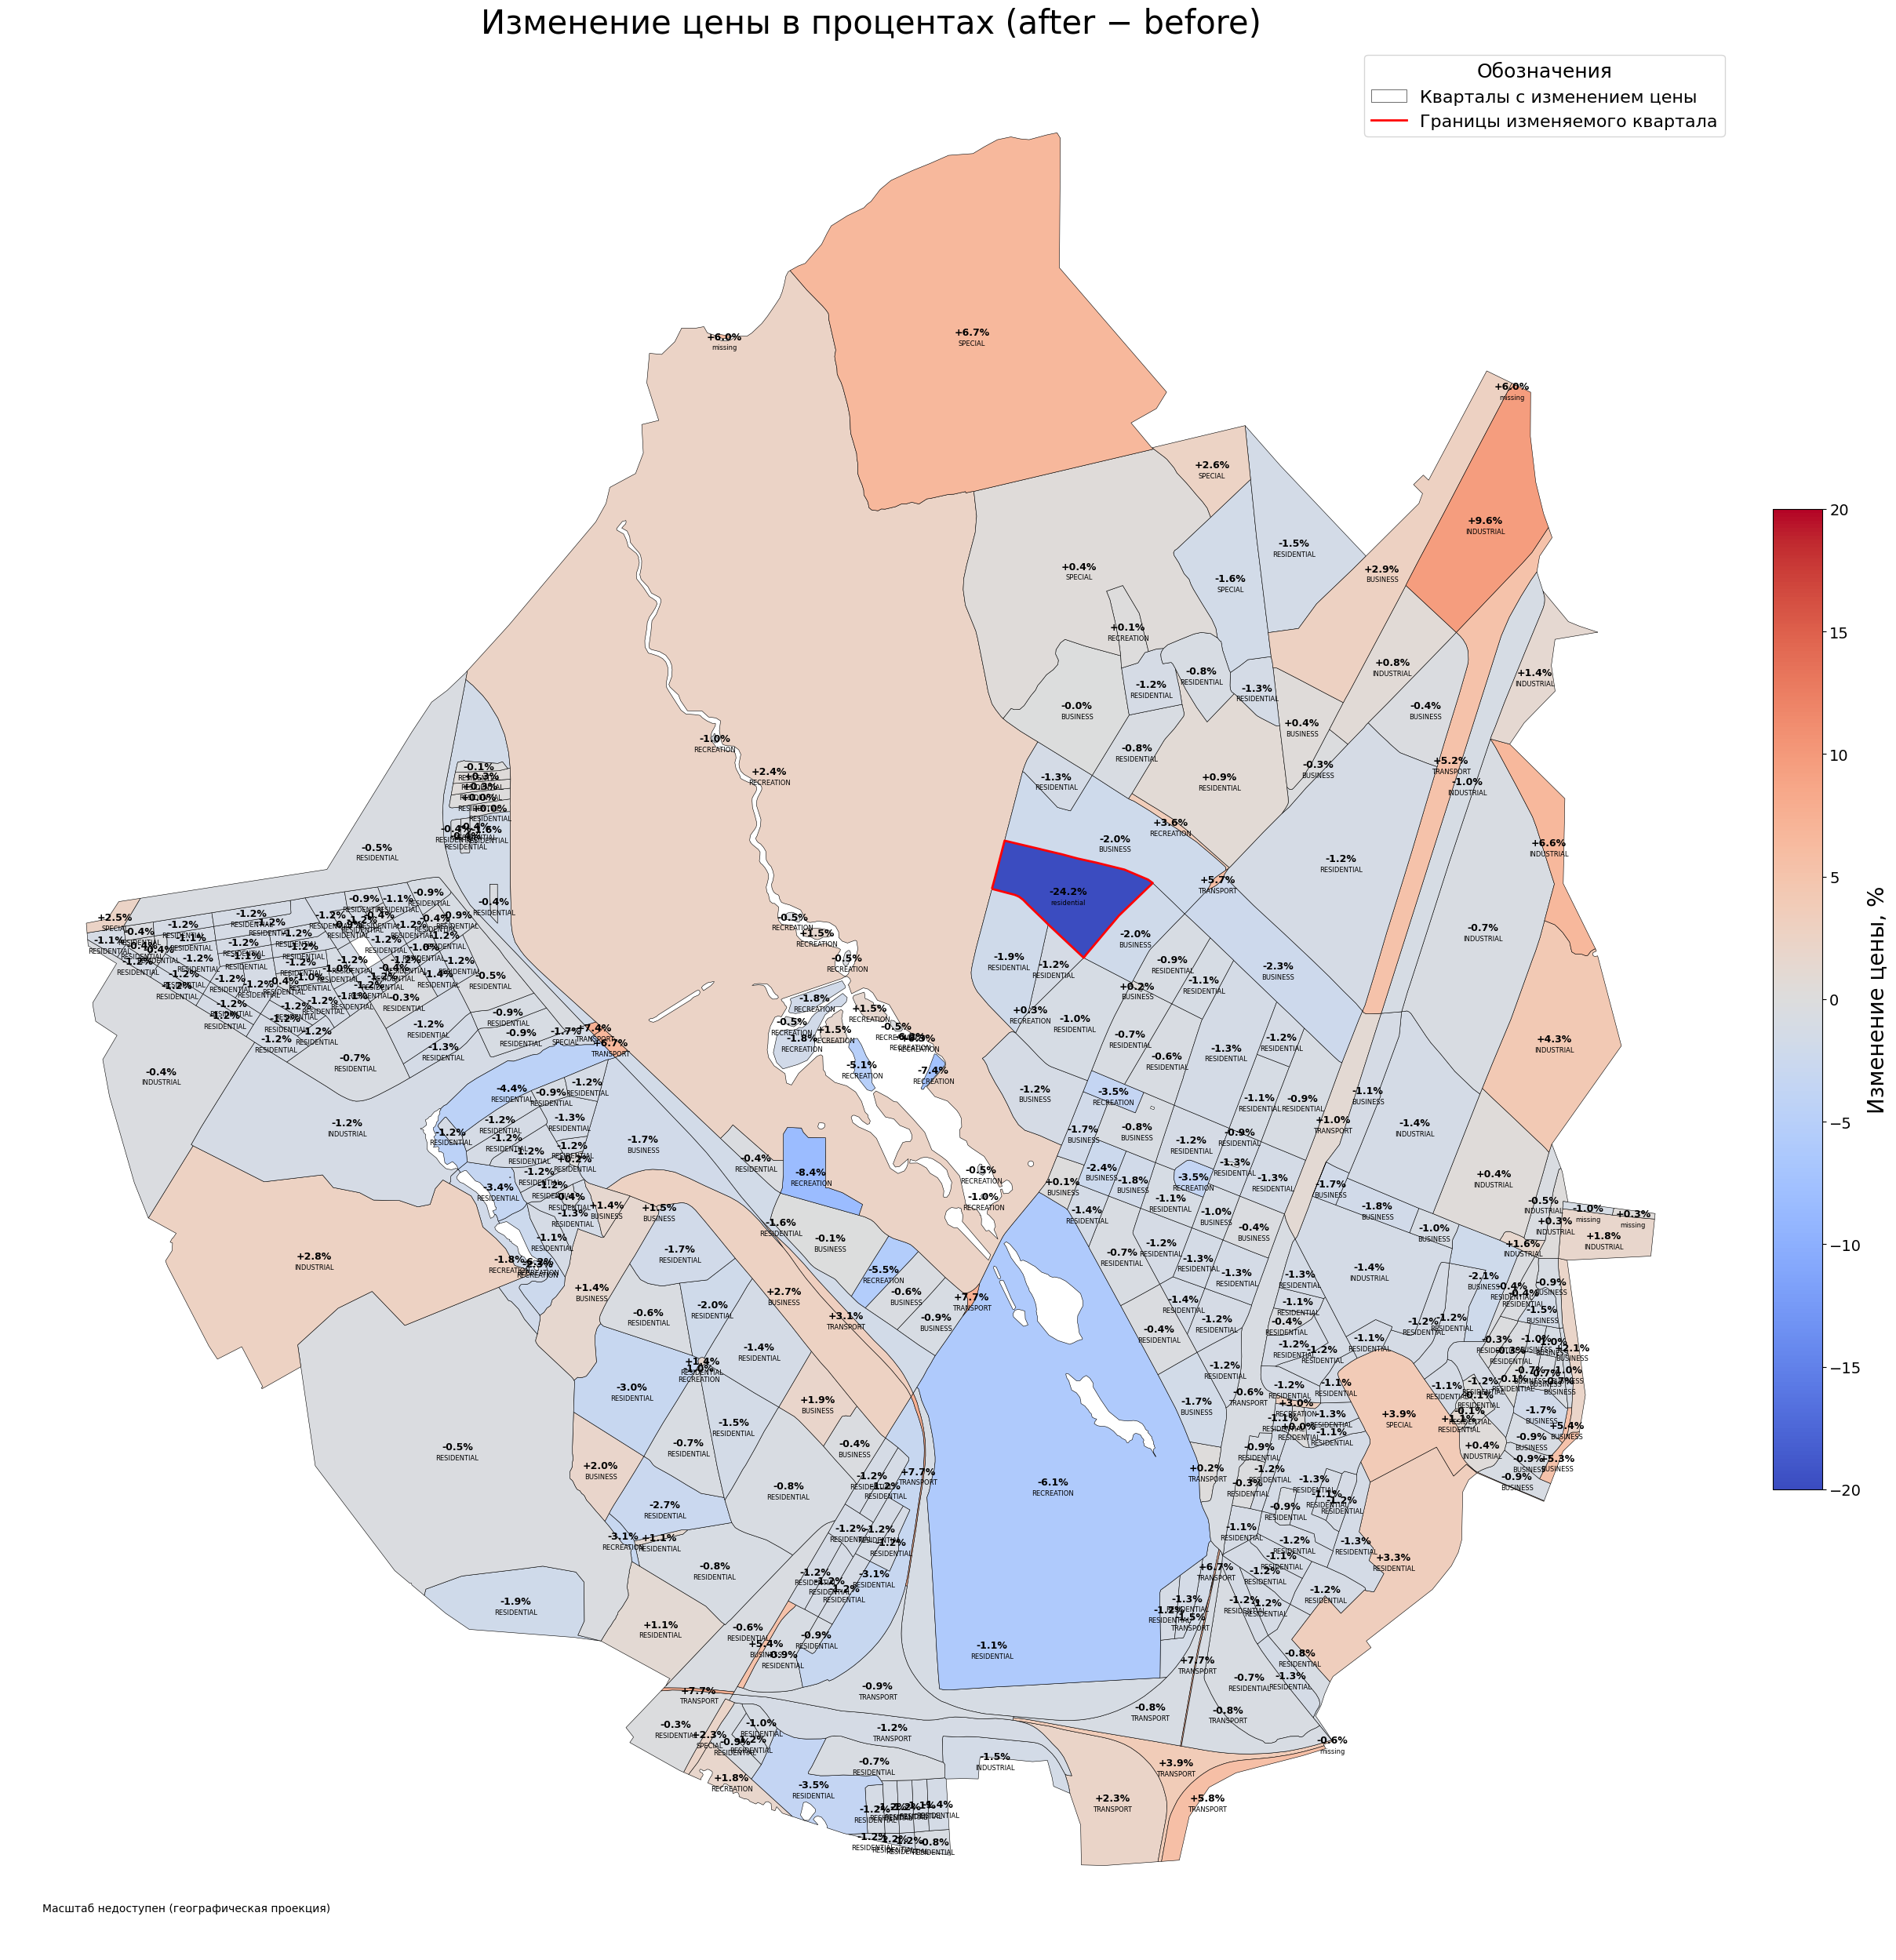


Статистика по кварталам в контексте (|Δ₽| > 1e-09):

Изменяемый квартал:
index | land_use | до (₽) → после (₽) | Δ₽ | Δ%
87 | residential | 1 044 985 582 ₽ → 792 129 439 ₽ | -252 856 143 ₽ | -24.2%

Кварталы в границах проекта:
Нет кварталов проекта с изменениями выше порога.

Кварталы в контексте:
index | land_use | до (₽) → после (₽) | Δ₽ | Δ%
311 | RESIDENTIAL | 558 068 634 ₽ → 553 862 944 ₽ | -4 205 690 ₽ | -0.8%
248 | TRANSPORT | 463 610 653 ₽ → 474 455 623 ₽ | +10 844 970 ₽ | +2.3%
298 | TRANSPORT | 90 038 010 ₽ → 93 514 156 ₽ | +3 476 146 ₽ | +3.9%
115 | RESIDENTIAL | 129 175 469 ₽ → 127 697 359 ₽ | -1 478 111 ₽ | -1.1%
317 | RESIDENTIAL | 157 610 237 ₽ → 155 474 763 ₽ | -2 135 474 ₽ | -1.4%
318 | INDUSTRIAL | 283 475 839 ₽ → 279 355 934 ₽ | -4 119 905 ₽ | -1.5%
225 | TRANSPORT | 237 712 832 ₽ → 235 715 613 ₽ | -1 997 219 ₽ | -0.8%
299 | TRANSPORT | 3 887 664 ₽ → 4 186 019 ₽ | +298 355 ₽ | +7.7%
5 | TRANSPORT | 134 459 896 ₽ → 132 456 034 ₽ | -2 003 862 ₽ | -1.5%
113 | RESIDENT

{'map':      residential  business  recreation  industrial  transport   special  \
 311     0.957390  0.000000    0.000000    0.000000   0.000000  0.000000   
 248     0.000000  0.000000    0.000000    0.063868   0.741221  0.000000   
 298     0.000000  0.000000    0.000000    0.000000   0.999329  0.000000   
 115     0.955669  0.000000    0.044331    0.000000   0.000000  0.000000   
 317     0.858357  0.000000    0.068465    0.000000   0.000000  0.000000   
 ..           ...       ...         ...         ...        ...       ...   
 290     0.742723  0.003805    0.014400    0.000177   0.000000  0.238896   
 288     0.035634  0.000000    0.946904    0.000000   0.000000  0.017463   
 247     0.015964  0.000000    0.062648    0.015946   0.047933  0.857510   
 345     0.000000  0.000000    0.000000    0.000000   0.173390  0.825889   
 285     0.000000  0.000000    0.000000    0.000000   0.007811  0.953935   
 
      agriculture             land_use     share  footprint_area  ...  \
 311  

In [42]:
plot_scenario_impact(
    blocks_before=blocks_after,
    blocks_after=modifier.apply(target_idx, params_repaired),
    orig_features=numeric_feats+cat_features,
    categorical_features=cat_features,
    model=model,
    target_idx=target_idx,
    figsize=(25, 35),
)

In [43]:
import pandas as pd

blocks_gen = modifier.apply(target_idx, params_repaired)   # без запятой

gen_blocks = pd.DataFrame(blocks_gen)

gen_blocks.head()

,residential,business,recreation,industrial,transport,special,agriculture,land_use,share,footprint_area,...,mxi,l,morphotype,area_accessibility,geometry,land_value,price_per_sotka,id,share_living,share_non_living
0,0.690207,0.211718,0.055976,0.0,0.042093,0.0,0.0,LandUse.RESIDENTIAL,0.690207,7383.849525,...,0.091908,1.371459,individual residential,10.063987,"POLYGON ((30.09367 59.55207, 30.09375 59.55215...",6.833466e+08,81712.868330,0,NaN,NaN
1,0.970519,0.029484,0.000000,0.0,0.000000,0.0,0.0,LandUse.RESIDENTIAL,0.970519,15304.958732,...,0.712492,5.824002,mid-rise,10.210398,"POLYGON ((30.09448 59.56164, 30.09448 59.56164...",8.727378e+08,207723.484640,1,NaN,NaN
2,0.936589,0.010562,0.052849,0.0,0.000000,0.0,0.0,LandUse.RESIDENTIAL,0.936589,17141.628200,...,0.786029,5.365401,mid-rise,8.669212,"POLYGON ((30.12546 59.58002, 30.12541 59.57998...",6.121753e+08,202047.687390,2,NaN,NaN
3,0.121353,0.819171,0.059489,0.0,0.000000,0.0,0.0,LandUse.BUSINESS,0.819171,9453.530183,...,0.198114,2.288643,low-rise model,7.467434,"POLYGON ((30.12501 59.56588, 30.12497 59.56582...",1.809802e+08,145310.813724,3,NaN,NaN
4,0.068737,0.931312,0.000000,0.0,0.000000,0.0,0.0,LandUse.BUSINESS,0.931312,8567.309559,...,0.095598,2.187029,low-rise model,8.285434,"POLYGON ((30.1249 59.56574, 30.12497 59.56582,...",1.709968e+08,143003.845248,4,NaN,NaN


In [44]:
gen_blocks.iloc[86]

residential                                                    0.327026
business                                                       0.089307
recreation                                                      0.03208
industrial                                                     0.011822
transport                                                      0.294651
special                                                        0.156279
agriculture                                                    0.088835
land_use                                            LandUse.RESIDENTIAL
share                                                          0.327026
footprint_area                                             38840.570199
build_floor_area                                          242613.675861
living_area                                               170804.194496
non_living_area                                            71809.481364
population                                                  8540

In [45]:
blocks_after.iloc[86]

residential                                                    0.690324
business                                                       0.219805
recreation                                                     0.089872
industrial                                                          0.0
transport                                                           0.0
special                                                             0.0
agriculture                                                         0.0
land_use                                            LandUse.RESIDENTIAL
share                                                          0.690324
footprint_area                                             33119.603537
build_floor_area                                          190588.496682
living_area                                               132192.815395
non_living_area                                            58395.681287
population                                                      

In [48]:
gen_blocks = gen_blocks.copy()
gen_blocks["is_project"] = False

# target_idx — индекс изменяемого квартала
if target_idx in gen_blocks.index:
    gen_blocks.loc[target_idx, "is_project"] = True
else:
    raise KeyError(f"target_idx={target_idx} не найден в gen_blocks.index")

investment_input = prepare_investment_input(
    gdf=gen_blocks,
    project_potential=potential_df,
)

summary = an.calculate_investment_metrics(
    investment_input,
    discount_rate=0.18,
    show_project_totals=True
)
summary

2026-02-17 18:27:07.877 | WARNING  | urbanomy.utils.investment_input:prepare_investment_input:452 - prepare_investment_input: колонка 'land_value_before' не найдена; значения скопированы из 'land_value'.


Project totals:
 • Land area:          705,080.04
 • Built area:         242,613.68
 • Land value:         1,066,618,958.46
 • Construction cost:  16,982,957,310.25
 • Investment need:    18,049,576,268.71
 • Spatial potential:  0.00
 • Project NPV:        2,736,271,403.39
 • Project IRR:        0.24
 • Project ROI:        3.96
 • Project PP (yrs):   6.22
 • Project EI:         73.58
 • Project INV score:  44.15


,land_use,land_area,land_value_before,built_area,land_value,construction_cost,investment_need,NPV,IRR,ROI,PP_years,EI,spatial_potential,INV
0,LandUse.RESIDENTIAL,705080.04,1.066619e+09,242613.68,1.066619e+09,1.698296e+10,1.804958e+10,2.736271e+09,0.24,3.96,6.22,73.58,0.0,44.15
